If you lack an adata file, then you can use the following command or visit [this website](https://figshare.com/ndownloader/files/44229635) to download it.

```bash
mkdir data
wget -O ./data/combosciplex.h5ad https://figshare.com/ndownloader/files/44229635

In [1]:
%load_ext autoreload
%autoreload 2
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch

from tqdm.notebook import tqdm

from scFM_density_estimation.models import *
from scFM_density_estimation.datamodules import *
from scFM_density_estimation.utils import *

In [77]:
def prepare_batch(X, C, num_classes, num_conditions, batch_size, device):
    indices = np.random.randint(X.shape[0], size=batch_size)
    x1 = torch.from_numpy(X[indices]).float().to(device)
    
    cond = []
    for i in range(num_conditions):
        cond.append(torch.nn.functional.one_hot(torch.from_numpy(C[:, i][indices]).long(),
                                                num_classes=num_classes[i]).float()
                   )
    cond = torch.cat(cond, dim=1).to(device)
    
    return x1, cond

def weighted_wasserstein(X, C, num_classes, model):
    ws_dist = 0
    combined_conditions = C.cpu().numpy()
    unique_conditions = np.unique(combined_conditions, axis=0)
    
    for condition in unique_conditions:
        mask = np.all(combined_conditions == condition, axis=1)
        generated_samples = model.run_simulation(X[mask], C[mask], n_steps=100)
        ws_dist += wasserstein(X[mask], generated_samples) * np.sum(mask)

    return ws_dist / C.shape[0]

In [3]:
adata = sc.read_h5ad("./data/combosciplex.h5ad")

In [4]:
# datamodule = scFMDataModule(
#     adata_path="./data/pbmc3k.h5ad",
#     label_key="louvain",
#     batch_size=256,
#     val_split=0.01,
#     test_split=0.01,
#     n_conds=8
# )
# datamodule.setup()
# train_dataloader = datamodule.train_dataloader()

In [53]:
label = "Drug1"
X = adata.obsm["X_pca"]
# C = np.stack([adata.obs[label].cat.codes.values.copy()], axis=1)
C = np.stack([adata.obs["Drug1"].cat.codes.values.copy(), adata.obs["Drug2"].cat.codes.values.copy()], axis=1)

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 2048
cond_dims = [8, 18]
num_cond = 2
dim = 50
alpha = 0.999
ema_loss = None
use_ot_sampler = False
model = ConditionalFlowMatching(input_dim=dim, hidden_dims=[1024, 1024, 1024, 1024],
                                   cond_dim=np.sum(cond_dims), use_encoder=False,
                                   use_ot_sampler=use_ot_sampler).to(device)
optimizer = model.configure_optimizers()

for k in tqdm(range(200000)):
    optimizer.zero_grad()

    x1, cond = prepare_batch(X, C, cond_dims, num_cond, batch_size, device)
    loss = model.shared_step(x1, cond)
    
    loss.backward()
    optimizer.step()

    if ema_loss is None:
        ema_loss = loss.item()
    else:
        ema_loss = alpha * ema_loss + (1 - alpha) * loss.item() 

    if (k + 1) % 1000 == 0:
        print(f"Step {k+1}, EMA Loss: {ema_loss:.3f}")
    
    if (k + 1) % 10000 == 0:
        x1, cond = prepare_batch(X, C, cond_dims, num_cond, 10000, device)
        ws_dist = weighted_wasserstein(x1, cond, cond_dims, model)
        print(f"Step {k+1}, Weighted Wasserstein distance: {ws_dist:.3f}")

    # if (k + 1) % 50000 == 0:
    #     x1, cond = prepare_batch(X, C, cond_dims, num_cond, 10000, device)
    #     generated_samples = model.run_simulation(x1, cond, n_steps=100)

    #     model.get_umap_reducer()
    #     data_umap = model.reducer.fit_transform(x1.cpu().numpy())
    #     generated_umap = model.reducer.transform(generated_samples.cpu().numpy())
        
    #     plot_simulation(generated_umap, data_umap,
    #                     np.argmax(cond.cpu().numpy(), axis=1),
    #                     size=0.5, plot_size=(7, 5))

  0%|          | 0/100000 [00:00<?, ?it/s]

Step 1000, EMA Loss: 2.733
Step 2000, EMA Loss: 2.176
Step 3000, EMA Loss: 1.965
Step 4000, EMA Loss: 1.885
Step 5000, EMA Loss: 1.852
Step 6000, EMA Loss: 1.839
Step 7000, EMA Loss: 1.832
Step 8000, EMA Loss: 1.828
Step 9000, EMA Loss: 1.825
Step 10000, EMA Loss: 1.823
Step 10000, Weighted Wasserstein distance: 9.071
Step 11000, EMA Loss: 1.822
Step 12000, EMA Loss: 1.821
Step 13000, EMA Loss: 1.819
Step 14000, EMA Loss: 1.817
Step 15000, EMA Loss: 1.816
Step 16000, EMA Loss: 1.815
Step 17000, EMA Loss: 1.814
Step 18000, EMA Loss: 1.813
Step 19000, EMA Loss: 1.813
Step 20000, EMA Loss: 1.812
Step 20000, Weighted Wasserstein distance: 9.033
Step 21000, EMA Loss: 1.812
Step 22000, EMA Loss: 1.811
Step 23000, EMA Loss: 1.810
Step 24000, EMA Loss: 1.810
Step 25000, EMA Loss: 1.809
Step 26000, EMA Loss: 1.809
Step 27000, EMA Loss: 1.808
Step 28000, EMA Loss: 1.808
Step 29000, EMA Loss: 1.807
Step 30000, EMA Loss: 1.806
Step 30000, Weighted Wasserstein distance: 9.049
Step 31000, EMA Loss: 

In [91]:
# torch.save(model.state_dict(), "./weights/combosciplex_dc_[1024, 1024, 1024, 1024]_2048.ckpt")
# model.load_state_dict(torch.load("./weights/combosciplex_dataloader.ckpt",  weights_only=False))

In [78]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# batch_size = 2048
# cond_dims = [8]
# num_cond = 1
# dim = 50
# use_ot_sampler = False
# model = ConditionalFlowMatching(input_dim=dim, hidden_dims=[1024, 1024, 1024, 1024],
#                                    cond_dim=np.sum(cond_dims), use_encoder=False,
#                                    use_ot_sampler=use_ot_sampler).to(device)
# model.load_state_dict(torch.load("./weights/combosciplex_[1024, 1024, 1024, 1024]_2048.ckpt",  weights_only=False))

/home/icb/egor.antipov/miniconda3/envs/scaling-transformers/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


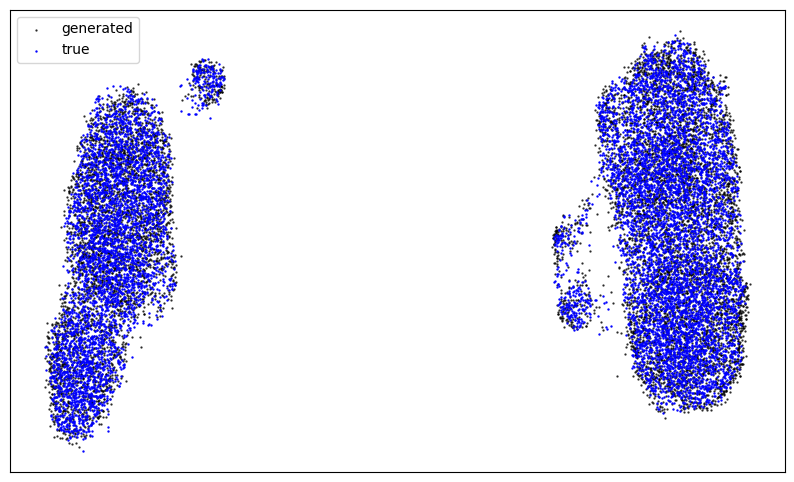

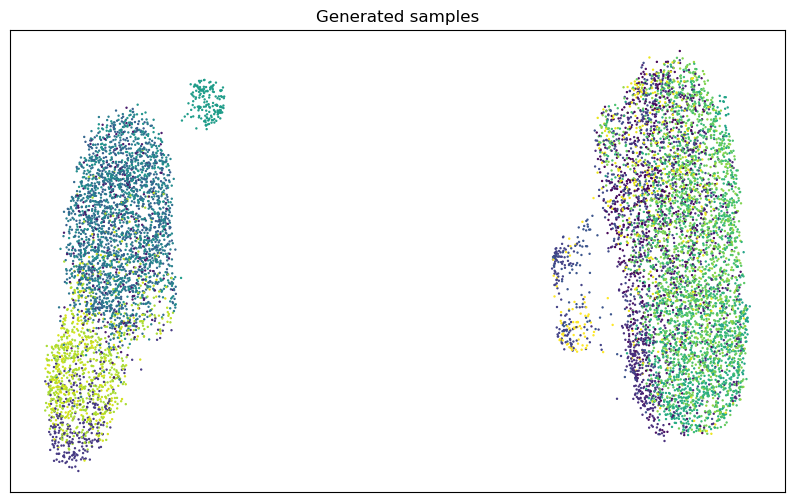

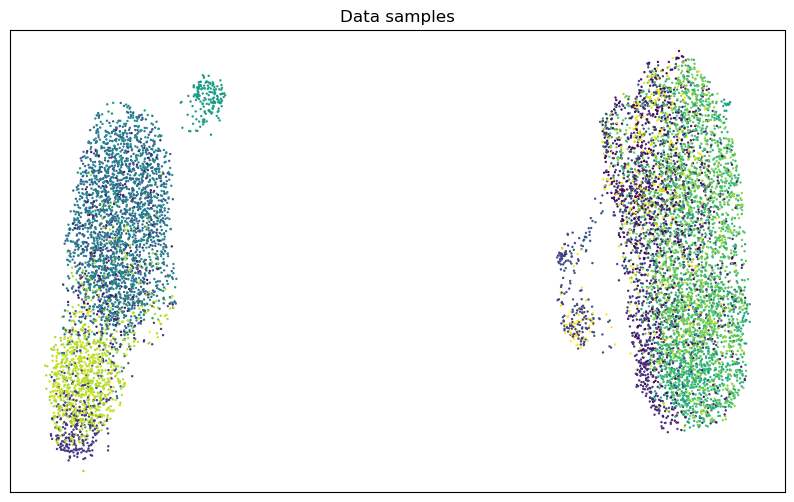

In [79]:
x1, cond = prepare_batch(X, C, cond_dims, num_cond, 10000, device)
generated_samples = model.run_simulation(x1, cond, n_steps=100)

model.get_umap_reducer()
data_umap = model.reducer.fit_transform(x1.cpu().numpy())
generated_umap = model.reducer.transform(generated_samples.cpu().numpy())

plot_simulation(generated_umap, data_umap, cond.cpu().numpy(), size=0.5, plot_size=(10, 6))

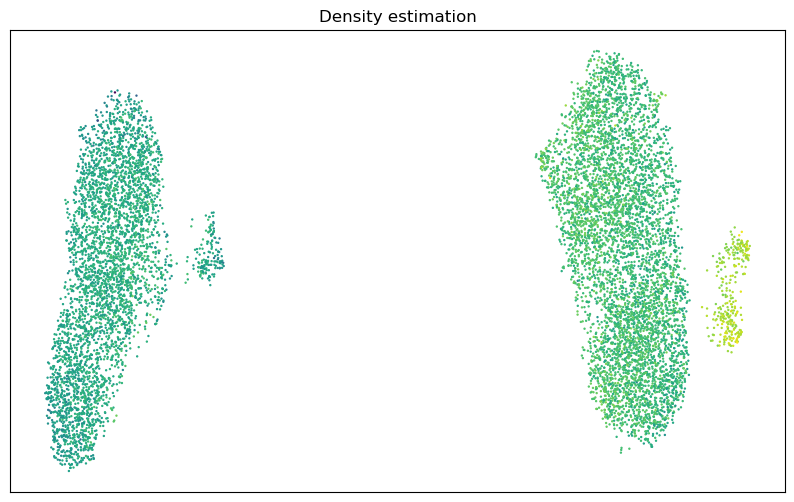

In [80]:
condition = [0, 11]
x1, cond = prepare_batch(X, C, cond_dims, num_cond, 10000, device)
cond = []
for i in range(num_cond):
    cond.append(torch.from_numpy(np.array([1 if j == condition[i] else 0 for j in range(cond_dims[i])]
                                         ).reshape(1, -1)).float().expand(x1.shape[0], cond_dims[i])
               )
cond = torch.cat(cond, dim=1).to(device)
log_density = model.estimate_log_density(x1, cond, n_steps=100)

model.get_umap_reducer(None)
data_umap = model.reducer.fit_transform(x1.cpu().numpy())

plot_densities(data_umap, log_density, size=0.5, plot_size=(10, 6))

In [81]:
# sc.pl.umap(adata, color="Drug2")

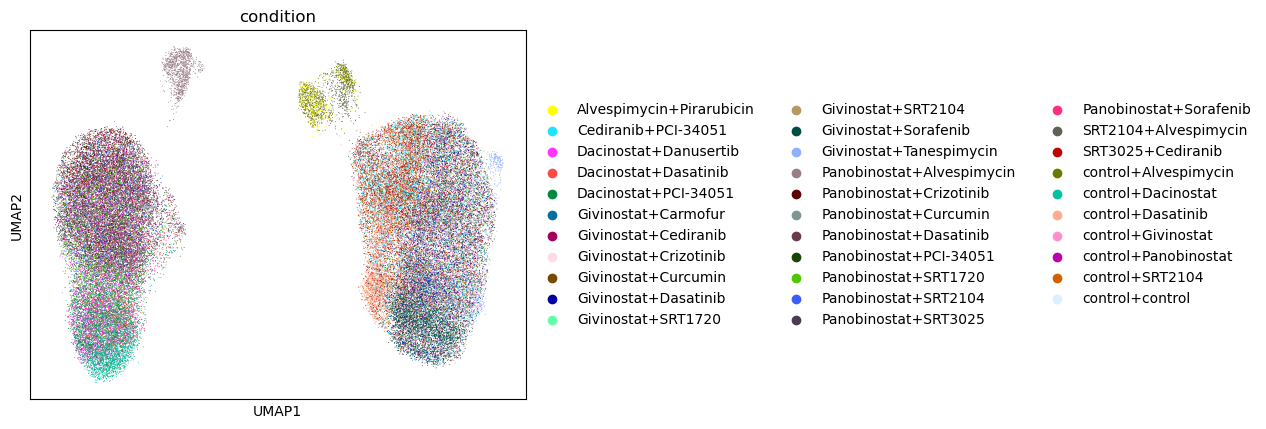

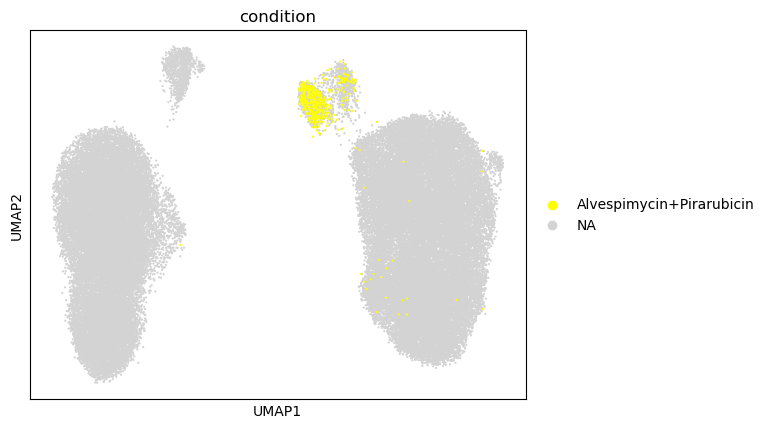

In [82]:
sc.pl.umap(adata, color="condition")
sc.pl.umap(adata, color="condition", groups="Alvespimycin+Pirarubicin", s=10)

  0%|          | 0/32 [00:00<?, ?it/s]

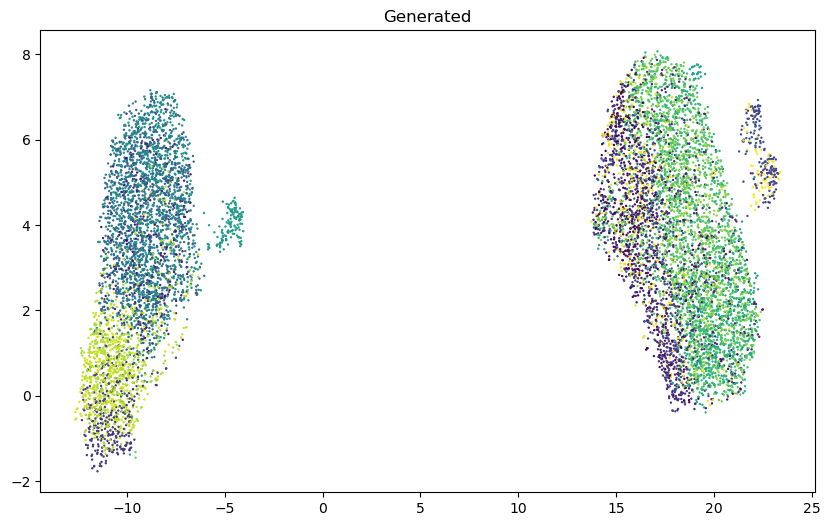

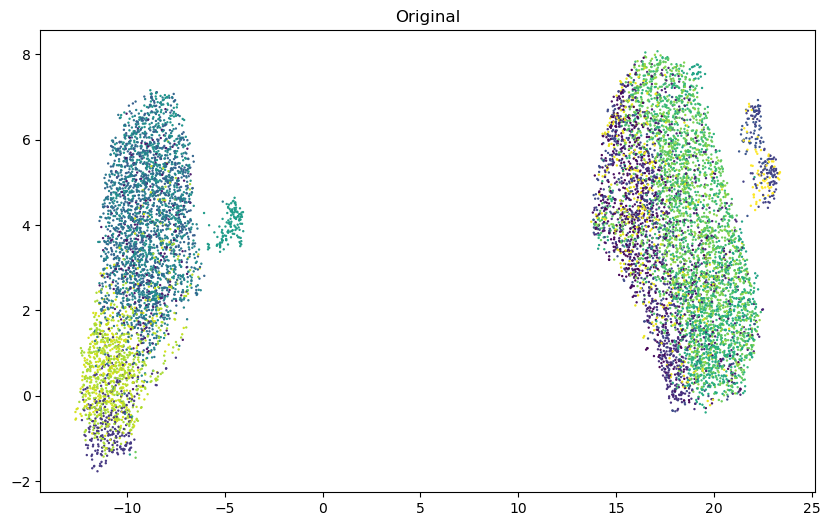

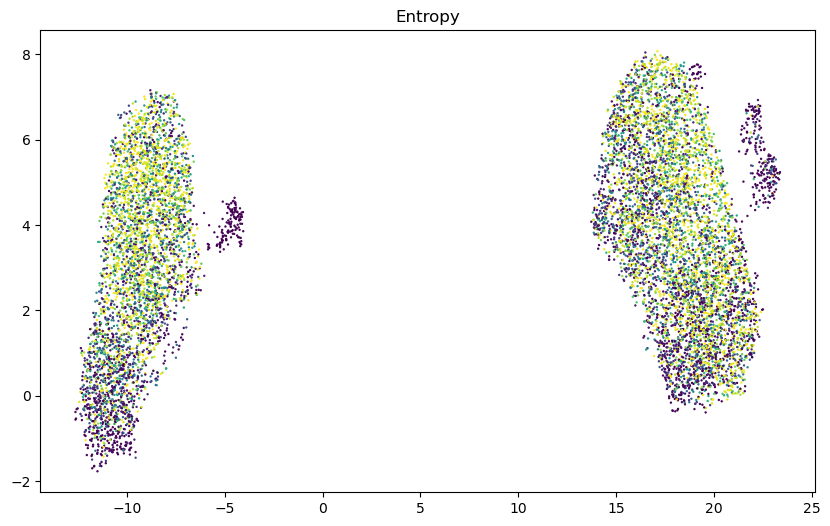

In [84]:
log_density = []
x1, cond_orig = prepare_batch(X, C, cond_dims, num_cond, 10000, device)
unique_conditions = np.unique(cond_orig.cpu().numpy(), axis=0)
for condition in tqdm(unique_conditions):
    cond = torch.from_numpy(condition).expand(cond_orig.shape).float().to(device)
    log_density.append(model.estimate_log_density(x1, cond, n_steps=100).reshape(-1, 1))
log_density = np.concatenate(log_density, axis=1)
color = np.argmax(log_density, axis=1)

def softmax(x):
    e_x = np.exp(x)
    return e_x / e_x.sum(axis=-1, keepdims=True)
    
entropy = np.max(softmax(log_density), axis=1)
entropy = entropy * (1 - entropy)

color_orig = np.zeros_like(color)
for i in range(unique_conditions.shape[0]):
    mask = np.all(cond_orig.cpu().numpy() == unique_conditions[i], axis=1)
    color_orig[mask] = i

model.get_umap_reducer(None)
data_umap = model.reducer.fit_transform(x1.cpu().numpy())

plt.figure(figsize=(10, 6))
plt.title("Generated")
plt.scatter(data_umap[:, 0], data_umap[:, 1], s=0.5, c=color)
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Original")
plt.scatter(data_umap[:, 0], data_umap[:, 1], s=0.5, c=color_orig)
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Entropy")
plt.scatter(data_umap[:, 0], data_umap[:, 1], s=0.5, c=entropy, cmap="viridis")
plt.show()

In [86]:
np.sum(color == color_orig) / color.shape[0]

0.8124

In [87]:
# log_density = []
# x1, cond_orig = prepare_batch(X, C, cond_dims, num_cond, 10000, device)
# for condition in tqdm([[i] for i in range(8)]):
#     cond = []
#     for i in range(num_cond):
#         cond.append(torch.from_numpy(np.array([1 if j == condition[i] else 0 for j in range(cond_dims[i])]
#                                              ).reshape(1, -1)).float().expand(x1.shape[0], cond_dims[i])
#                    )
#     cond = torch.cat(cond, dim=1).to(device)
#     log_density.append(model.estimate_log_density(x1, cond, n_steps=100).reshape(-1, 1))
# log_density = np.concatenate(log_density, axis=1)

In [88]:
np.max(log_density)

-36.748604

(array([2577.,  784.,  610.,  506.,  484.,  439.,  435.,  559.,  863.,
        2743.]),
 array([0.        , 0.025     , 0.05      , 0.075     , 0.1       ,
        0.125     , 0.15000001, 0.175     , 0.2       , 0.22499999,
        0.25      ]),
 <BarContainer object of 10 artists>)

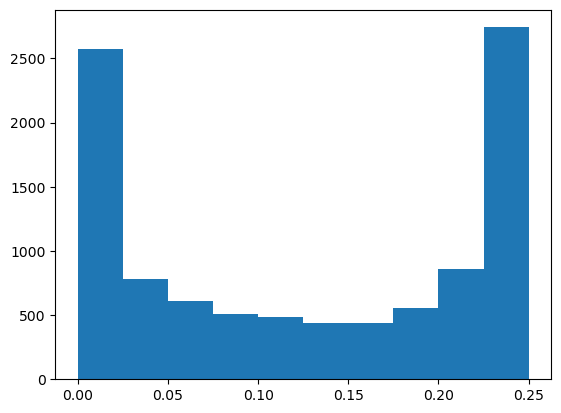

In [89]:
plt.hist(entropy)